# Unified Time-Lapse ERT Workflow with Climate Integration

This notebook runs a time-lapse ERT workflow with climate data from a request written in plain language, through `BaseAgent.run_unified_agent_workflow()`.

## Time-Lapse ERT Workflow

Monitor temporal changes in subsurface resistivity to track:
- **Moisture infiltration** and drainage
- **Seasonal variations** in water content
- **Hydrological processes** over time

## How It Works

```python
# 1. Describe the task in plain language
user_request = "Run a time-lapse ERT inversion on 4 files: ..."

# 2. A language model turns the request into a workflow configuration
config = context_agent.parse_request(user_request)
config["user_request"] = user_request   # the controller reads the request too

# 3. The workflow controller runs it, choosing each step from what the run holds
results, plan, interpretation, files = BaseAgent.run_unified_agent_workflow(
    config, api_key, llm_model, llm_provider, output_dir
)

# 4. Temporal resistivity changes, the climate series and the report
```

`run_unified_agent_workflow()` hands the configuration to the workflow controller in `PyHydroGeophysX.agents.runtime`. Before each step the controller lists the tools whose inputs the run already holds (load the surveys, invert them, evaluate the inversion, convert to water content, fetch climate data, invert a seismic line, derive structural constraints, fuse methods, write the report), picks one, and reads its result before picking the next. With an API key the language model picks; without one, the controller takes the runnable tools in dependency order. The execution plan it returns lists the steps that ran, each with the reason it was chosen.

With two or more surveys loaded, the controller offers the time-lapse inversion instead of the single-survey one, and with a site and a period in the configuration it offers the climate step.

## Key Features

✅ **Temporal Regularization**: Smooths changes between time steps
✅ **Climate Integration**: Daily precipitation, temperature and evapotranspiration at the site, from a saved series or from Open-Meteo (ERA5)
✅ **Steps Chosen From the Data**: The execution plan lists each step that ran and why

---

## 1. Setup and Imports

In [1]:
import json
import os
from pathlib import Path

import numpy as np

from PyHydroGeophysX.agents import BaseAgent, ContextInputAgent

# Where this notebook writes its results
default_output_dir = Path('results/unified_workflow_timelapse')
default_output_dir.mkdir(parents=True, exist_ok=True)

print("✓ PyHydroGeophysX agents imported")
print(f"✓ Output directory: {default_output_dir}")

✓ PyHydroGeophysX agents imported
✓ Output directory: results\unified_workflow_timelapse


## 2. Configure the Language Model

The request is parsed by a language model. Set `OPENAI_API_KEY` to parse it live. Without a key the notebook uses the configuration the parser produced for this request in the reference run, so it still runs, on the same configuration as the reference run; the workflow controller then takes the runnable steps in dependency order instead of asking the model.

In [2]:
# Configure API (set OPENAI_API_KEY in the environment, or change the provider)
llm_provider = 'openai'  # Options: 'openai', 'gemini', 'claude'
llm_model = 'gpt-4o-mini'
api_key = os.getenv('OPENAI_API_KEY')

if api_key:
    # Natural-language parsing of the request
    context_agent = ContextInputAgent(api_key=api_key, model=llm_model, llm_provider=llm_provider)
    print(f"✓ Using {llm_provider} with model {llm_model}")
else:
    context_agent = None
    print("ℹ️  No API key: the notebook uses the recorded configuration, and the")
    print("   workflow controller takes the runnable steps in dependency order")

ℹ️  No API key: the notebook uses the recorded configuration, and the
   workflow controller takes the runnable steps in dependency order


## 3. Time-Lapse ERT Workflow Example

This example uses:
- **4 E4D format files** from Mt. Snodgrass, Colorado (March to June 2022), the first as the baseline
- **Difference time-lapse inversion** with temporal regularization (λ_t = 10) between surveys
- **Daily weather** at the site for March to June 2022, read from the series bundled in `data/climate`

The controller loads the four surveys, reads the climate series, runs the time-lapse inversion, evaluates it, and writes the time-lapse report. The request asks to monitor moisture infiltration, so the controller also converts the models to water content.

In [3]:
# PART 1: ERT INVERSION REQUEST
# Focus on: data files, instrument, inversion settings, regularization
user_request_inversion = """
I need to run a TIME-LAPSE ERT inversion to monitor moisture infiltration.

DATA FILES FOR TIME-LAPSE INVERSION:
Please use these 4 E4D format data files located in folder data/ERT/E4D:

File 1 (BASELINE): 2022-03-26_0030.ohm
File 2: 2022-04-26_0030.ohm
File 3: 2022-05-26_0030.ohm
File 4: 2022-06-26_0030.ohm

INVERSION SETTINGS:
- Inversion Type: TIME-LAPSE (difference method)
- Instrument Type: E4D
- Data Directory: data/ERT/E4D
- Baseline File: First file (2022-03-26_0030.ohm)
- Temporal Regularization Parameter: 10
- Spatial Regularization (lambda): 15
- Maximum Iterations: 10
"""

# PART 2: CLIMATE/SITE REQUEST
# Focus on: coordinates, dates, climate variables, site information
user_request_climate = """

CLIMATE DATA INTEGRATION:
Fetch meteorological data for correlation analysis with ERT monitoring:
- Site Coordinates: 38.92584°N, -106.97998°W
- Date Range: March 2022 to June 2022
- Climate Variables: precipitation (prcp), minimum temperature (tmin), 
  maximum temperature (tmax), solar radiation (srad), day length (dayl)
- Calculate Potential Evapotranspiration using Penman-Monteith method
- Temporal Resolution: Daily measurements
"""

# Combine both requests for the agent
user_request = user_request_inversion + "\n\n" + user_request_climate

# The configuration the parser produced for this request in the reference run.
# It is used when no API key is set, so the notebook still runs on that configuration.
RECORDED_CONFIG = json.loads(r"""
{
  "inversion_mode": "time-lapse",
  "time_lapse_files": [
    "data/ERT/E4D/2022-03-26_0030.ohm",
    "data/ERT/E4D/2022-04-26_0030.ohm",
    "data/ERT/E4D/2022-05-26_0030.ohm",
    "data/ERT/E4D/2022-06-26_0030.ohm"
  ],
  "time_lapse_method": "difference",
  "temporal_regularization": 10,
  "data_file": "data/ERT/E4D/2022-03-26_0030.ohm",
  "project_dir": "data/ERT/E4D",
  "instrument": "E4D",
  "inversion_params": {
    "lambda": 15,
    "max_iterations": 10,
    "method": "cgls",
    "use_gpu": false
  },
  "fusion_pattern": null,
  "methods": [
    "ert"
  ],
  "ert_file": "data/ERT/E4D/2022-03-26_0030.ohm",
  "ert_params": {
    "lambda": 15,
    "max_iterations": 10,
    "limits": [
      null,
      null
    ]
  },
  "output_dir": null,
  "coverage_threshold": null,
  "use_climate": true,
  "climate_config": {
    "coords": [
      -106.97998,
      38.92584
    ],
    "dates": [
      "2022-03-01",
      "2022-06-30"
    ],
    "variables": [
      "prcp",
      "tmin",
      "tmax",
      "srad",
      "dayl"
    ],
    "pet_method": "penman_monteith",
    "time_scale": "daily",
    "region": "na",
    "antecedent_days": [
      1,
      3,
      7,
      14,
      30
    ],
    "crs": 4326,
    "output": "data/climate/mt._snodgrass_monitoring_site_climate.csv"
  },
  "site_info": {
    "name": "Mt. Snodgrass Monitoring Site",
    "location": "Near Crested Butte, Colorado, USA",
    "coordinates": "38.92584°N, -106.97998°W",
    "elevation": "3,150 meters"
  },
  "crs": "local",
  "use_seismic": false,
  "run_uncertainty": true,
  "n_realizations": 100,
  "petrophysical_params": {},
  "baseline_file": "data/ERT/E4D/2022-03-26_0030.ohm"
}
""")

print("=" * 70)
print("USER REQUEST:")
print(user_request)
print("=" * 70)

if context_agent is not None:
    print("\n🤖 Parsing request...")
    config = context_agent.parse_request(user_request)
else:
    config = json.loads(json.dumps(RECORDED_CONFIG))   # a fresh copy
    print("\nℹ️  Using the recorded configuration")
# The controller reads the request too: what it asks for, and the report quotes it
config["user_request"] = user_request

# The daily series for this site and period is bundled in data/climate, so the
# notebook also runs without a network, on the same series every time.
# Delete this line to fetch the series from Open-Meteo instead.
config.setdefault("climate_config", {})["csv_file"] = "data/climate/mt._snodgrass_monitoring_site_climate.csv"
print(json.dumps({key: value for key, value in config.items() if key != "user_request"},
                 indent=2, default=str))

# The workflow controller chooses each step from the tools whose inputs exist
print("\n🚀 Running the workflow...")
output_dir = Path('results/unified_workflow/example2')
results, execution_plan, interpretation, report_files = BaseAgent.run_unified_agent_workflow(
    config, api_key, llm_model, llm_provider, output_dir
)

USER REQUEST:

I need to run a TIME-LAPSE ERT inversion to monitor moisture infiltration.

DATA FILES FOR TIME-LAPSE INVERSION:
Please use these 4 E4D format data files located in folder data/ERT/E4D:

File 1 (BASELINE): 2022-03-26_0030.ohm
File 2: 2022-04-26_0030.ohm
File 3: 2022-05-26_0030.ohm
File 4: 2022-06-26_0030.ohm

INVERSION SETTINGS:
- Inversion Type: TIME-LAPSE (difference method)
- Instrument Type: E4D
- Data Directory: data/ERT/E4D
- Baseline File: First file (2022-03-26_0030.ohm)
- Temporal Regularization Parameter: 10
- Spatial Regularization (lambda): 15
- Maximum Iterations: 10




CLIMATE DATA INTEGRATION:
Fetch meteorological data for correlation analysis with ERT monitoring:
- Site Coordinates: 38.92584°N, -106.97998°W
- Date Range: March 2022 to June 2022
- Climate Variables: precipitation (prcp), minimum temperature (tmin), 
  maximum temperature (tmax), solar radiation (srad), day length (dayl)
- Calculate Potential Evapotranspiration using Penman-Monteith method

[PyHydroGeophysX] ResIPy is not installed; using this package's own readers. Install with: pip install "PyHydroGeophysX[ert]"
[PyHydroGeophysX] PyGIMLi loaded successfully


[PyHydroGeophysX] SimPEG loaded successfully (version 0.25.2)
[PyHydroGeophysX] Reading ERT data without ResIPy.
ResIPy is the recommended ERT reader: it covers more instrument formats than this package reads on its own.
    pip install "PyHydroGeophysX[ert]"        (or: pip install resipy)

If the install or the import fails:
  * a compiler or build error: ResIPy carries compiled solvers, and a cloud image or slim container often has no toolchain. Try 'pip install --only-binary :all: resipy', or build the environment from conda-forge.
  * an import error after a successful install: usually a NumPy or Python version mismatch. 'pip check' names the conflict.
  * no network: install it into the image ahead of time; the readers below need nothing extra and will keep working meanwhile.

Without ResIPy this package reads: ABEM-Lund, ARES, BERT, DAS-1, E4D, Lippmann, ResInv, Sting, Subsurface Insights. Any other format needs it.
[PyHydroGeophysX] Attempting to parse ERT data with E4D parser.

[ert_loader] [INFO] Loading data from data\ERT\E4D\2022-03-26_0030.ohm (E4D format)


   No reciprocal pairs found; using source 'dev' error estimates (mean: 0.0960)
[ert_loader] [INFO] Loaded 112 electrodes, 3647 measurements
[ert_loader] [INFO] Running quality control checks


...

[report_generator] [INFO] Saved baseline resistivity plot


[report_generator] [INFO] Saved all timesteps resistivity plot


[report_generator] [INFO] Saved time-lapse resistivity percentage changes plot


[report_generator] [INFO] Saved time-lapse resistivity absolute changes plot


[report_generator] [INFO] Saved time-lapse water content plot
[report_generator] [WARNING] markdown package not installed; skipping the PDF (the Markdown report is still written)
[report_generator] [INFO] Time-lapse report saved to results\unified_workflow\example2\time_lapse_report.md


## 4. Results

The execution plan lists every step the controller took, with the reason it chose it, its status and its run time. The interpretation below it is the controller's own account of the run.

In [4]:
print("=" * 70)
print("STEPS THE CONTROLLER TOOK")
print("=" * 70)
for i, step in enumerate(execution_plan, 1):
    print(f"{i}. {step['step']} ({step['agent']}): {step['status']}, {step['seconds']:.0f} s")
    print(f"   why: {step['reason']}")

print(f"\nStatus: {results.get('status')}")
for warning in results.get('warnings', []):
    print(f"  ! {warning}")

evaluation = results.get('evaluation_results') or {}
fit = (evaluation.get('quality_metrics') or {}).get('data_fit') or {}
if fit.get('final_chi2') is not None:
    print(f"\nData fit: chi² = {fit['final_chi2']:.2f} (target 1)")

models = results.get('final_models')
if models is not None:
    print(f"\n📊 Time-lapse results: {np.asarray(models).shape[1]} time steps, "
          f"{np.asarray(models).shape[0]} model cells")
for index, step in enumerate(results.get('time_lapse_water_content') or [], 1):
    wc = np.asarray(step.get('water_content_mean'), dtype=float)
    wc_std = np.asarray(step.get('water_content_std'), dtype=float)
    print(f"   survey {index} water content: mean {np.nanmean(wc):.3f} ± {np.nanmean(wc_std):.3f}")
climate = results.get('climate_data') or {}
if isinstance(climate, dict) and climate.get('metadata'):
    meta = climate['metadata']
    print(f"🌤️  Climate: {meta.get('source')}, {meta['dates'][0]} to {meta['dates'][1]}, "
          f"{', '.join(meta.get('variables', []))}")
    for note in climate.get('notes') or []:
        print(f"   note: {note}")

if report_files:
    print(f"\n📄 Report files:")
    for name, path in report_files.items():
        print(f"  - {name}: {path}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(interpretation)

STEPS THE CONTROLLER TOOK
1. Load ERT data (ERTLoaderAgent): ok, 5 s
   why: next available step
2. Fetch climate data (ClimateDataAgent): ok, 0 s
   why: next available step
3. Run time-lapse inversion (ERTInversionAgent): ok, 298 s
   why: next available step
4. Evaluate inversion quality (InversionEvaluationAgent): ok, 0 s
   why: next available step
5. Convert to water content (PetrophysicsAgent): ok, 1 s
   why: next available step
6. Fuse methods (DataFusionAgent): ok, 0 s
   why: next available step
7. Generate report (ReportAgent): ok, 8 s
   why: next available step

Status: success
  ! The exported model carries no layer markers: The cell markers do not describe geological structure (2025 markers for 2025 cells), so the section is treated as a single unit with one petrophysical parameter set. Supplying a layered model is what would let parameters vary with depth.
  ! Water content is too uncertain to interpret quantitatively. The mean uncertainty (+/-0.128) covers 71% of the 

### Figures

The report agent saves its figures beside the report; they are shown here.

baseline resistivity


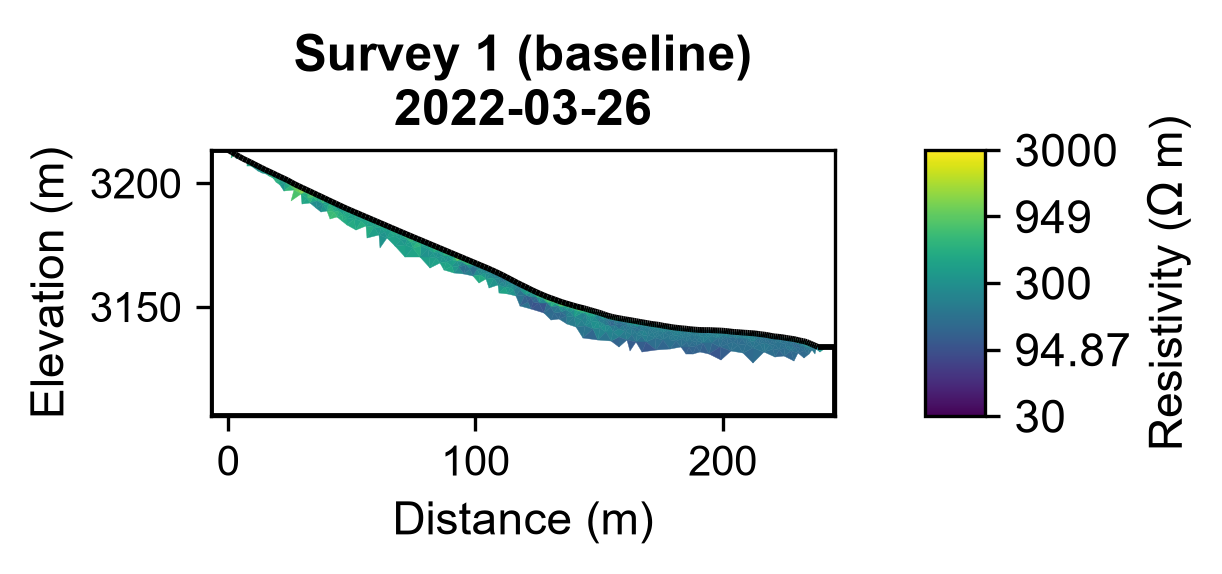

timelapse all resistivity


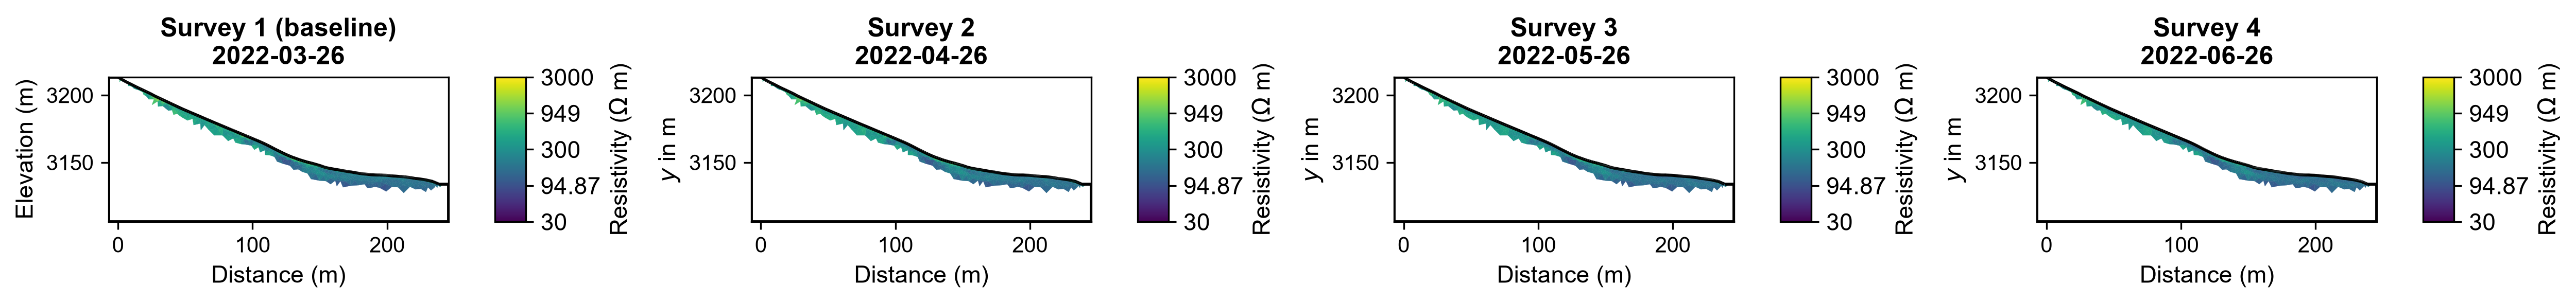

timelapse changes percent


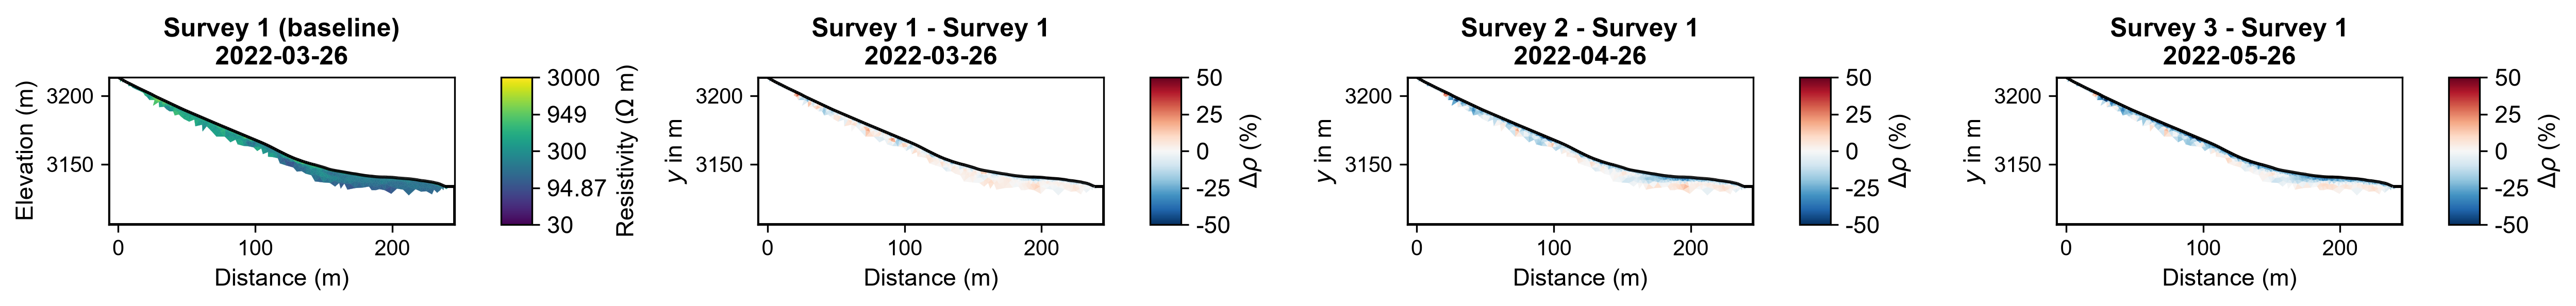

timelapse changes absolute


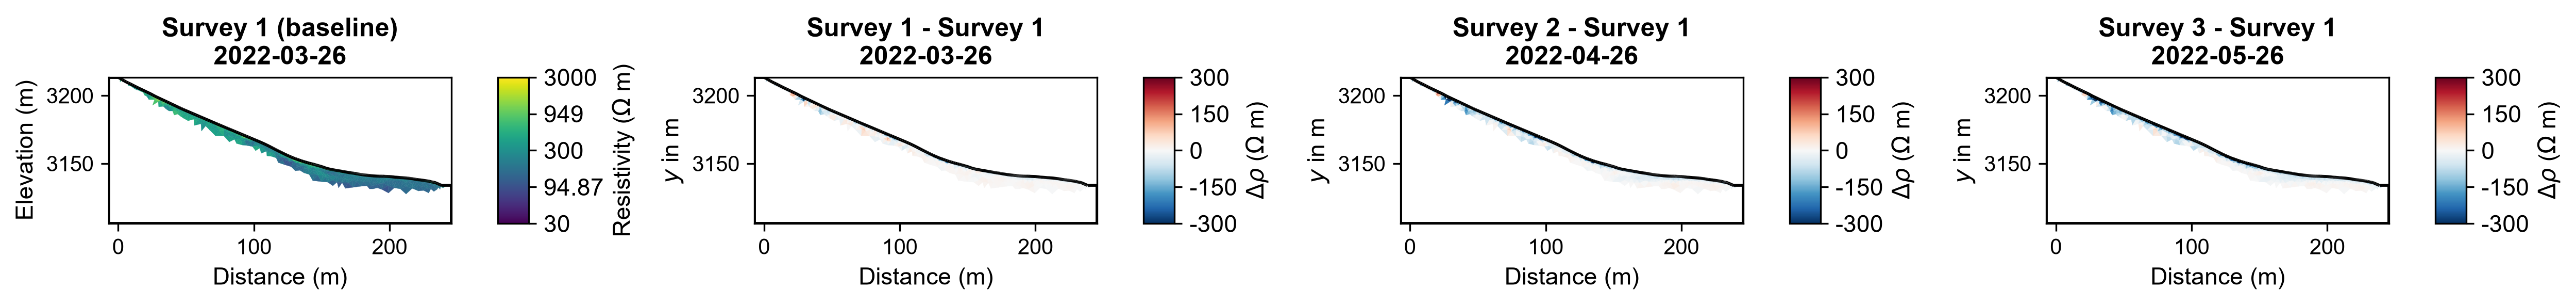

timelapse water content


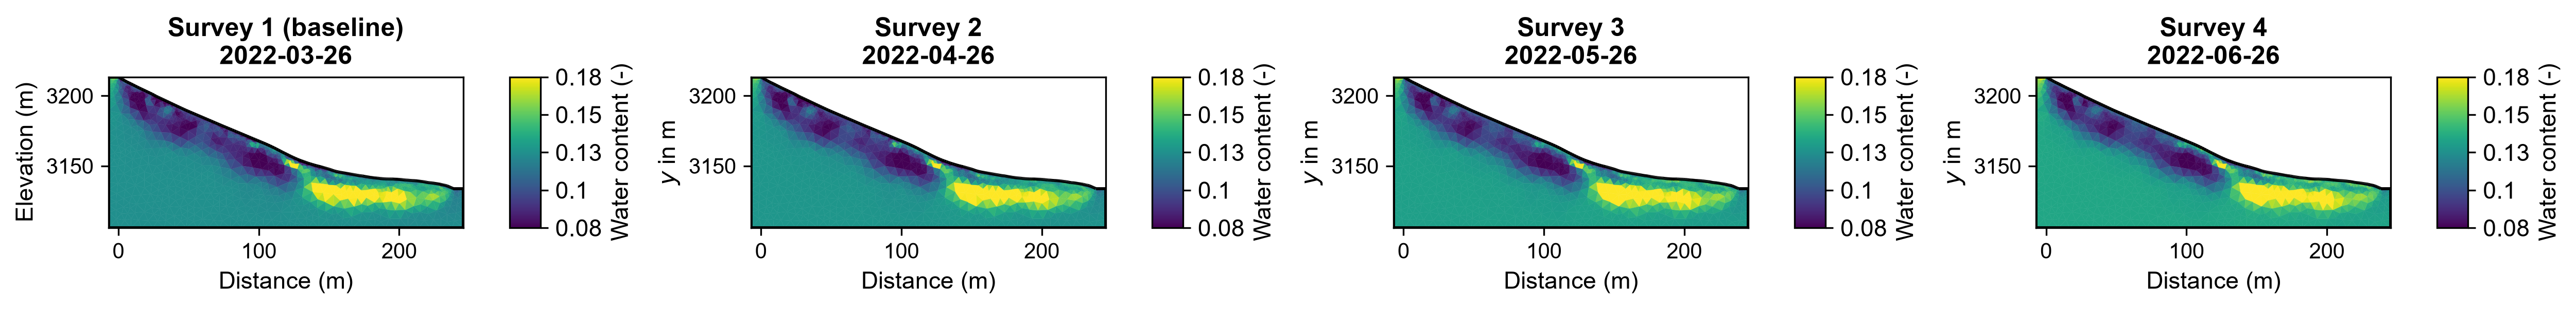

In [5]:
from IPython.display import Image, display

for name, path in (report_files or {}).items():
    if str(path).lower().endswith('.png') and Path(path).exists():
        print(name.replace('visualization_', '').replace('_', ' '))
        display(Image(filename=str(path)))

## 4. Debugging Tips

If you encounter issues with the time-lapse workflow:

### Common Issues

1. **"No time-lapse files detected"**
   - Check that multiple files are mentioned in the request
   - Ensure file paths are correct (relative to `data/ERT/E4D/`)

2. **"Climate data fetch failed"**
   - `ClimateDataAgent` requests the daily series from the Open-Meteo historical-weather API (`archive-api.open-meteo.com`); check the internet connection
   - The reanalysis is published about a week behind, so the most recent days may have no values yet

3. **"Could not extract dates from filenames"**
   - Dates must be in YYYY-MM-DD format (e.g., `2022-03-26`)
   - If using different format, update the regex pattern

4. **"Need at least 2 datasets for time-lapse"**
   - At least 2 ERT files are required for time-lapse
   - Check that files loaded successfully

### Output Files

After successful execution, you'll find in `results/unified_workflow/example2/`:
- **`climate/climate_data.csv`** - Daily Open-Meteo (ERA5) weather at the site, with its metadata in `climate_data.json`, when the series is fetched rather than read from `data/climate`
- **`inversion/`** - The surveys as they went into the time-lapse inversion
- **`ert_model/`** - The resistivity models, their coverage and the mesh
- **`time_lapse_report.md`** - The report, with its figures as PNG files


## Summary

- **One entry point**: `BaseAgent.run_unified_agent_workflow()` takes the parsed configuration of any request.
- **Steps chosen from the data**: several surveys make the controller offer the time-lapse inversion, and a site with a period makes it offer the climate step; the execution plan lists only the steps that ran.
- **Other requests, same call**: `Ex_Unified_Workflow_ex1` (one survey to water content) and `Ex_Unified_Workflow_ex3` (seismic-constrained ERT with layer-specific petrophysics) change only the request.
- **Step by step**: to approve each step before it runs, pass an approval function:

```python
from PyHydroGeophysX.agents.runtime.modes import step_by_step

def approve(step):
    return 'proceed' if input(f"Run '{step['label']}'? [y/n] ") == 'y' else 'stop'

BaseAgent.run_unified_agent_workflow(config, api_key, llm_model, llm_provider, output_dir,
                                     on_step=step_by_step(approve))
```

- **The previous pipeline**: set `PHGX_LEGACY_WORKFLOW=1` to run the fixed per-type pipeline the controller replaced.

### Next: Try the Streamlit Web App

For an interface without code, check out `app_geophysics_workflow.py`, a web UI where you can:
- Input natural language descriptions
- Upload data files
- Get results and reports automatically

Run with: `streamlit run app_geophysics_workflow.py`